# Glass dataset: KPCA + LDA -> kNN and NCC

This notebook:
1. Loads the Glass dataset from `./glass/class.scale.txt` via `load_glass`.
2. Splits into train/test with stratification.
3. Applies **Kernel PCA (KPCA)** then **Linear Discriminant Analysis (LDA)** for dimensionality reduction.
4. Trains and evaluates:
   - **k-Nearest Neighbors (kNN)**
   - **Nearest Class Centroid (NCC / NearestCentroid)**

Notes:
- Glass is **multi-class** and can be **imbalanced**, so we report **Accuracy** and **F1 (macro/weighted)**.
- KPCA is unsupervised; LDA is supervised and is applied after KPCA.


Load libraries

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

from data_loader import load_glass

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


In [2]:
# Load data
glass = load_glass("glass")
X, y = glass["x"], glass["y"]

feature_names = glass.get("feature_names", None)
class_names = glass.get("class_names", None)

print("X:", X.shape, "y:", y.shape)
print("mapped classes:", np.unique(y), "n_classes:", len(np.unique(y)))
if class_names is not None:
    print("class_names:", class_names)


X: (214, 9) y: (214,)
mapped classes: [0 1 2 3 4 5] n_classes: 6
class_names: {0: 'building_windows_float_processed', 1: 'building_windows_non_float_processed', 2: 'vehicle_windows_float_processed', 3: 'containers', 4: 'tableware', 5: 'headlamps'}


In [3]:
# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=0,
    stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (149, 9) Test: (65, 9)


## Cross-validation strategy

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

## Common pipeline: StandardScaler -> KPCA -> LDA -> Classifier

Even though `class.scale.txt` is typically scaled, we keep `StandardScaler` for robustness.
If you want to remove it, set the scaler step to `"passthrough"`.


In [12]:
n_classes = len(np.unique(y_train))
lda_cap = n_classes - 1
print("n_classes:", n_classes, "| LDA cap (n_classes-1):", lda_cap)

kpca_dims = [2, 3, 5, 7, 9]

def valid_lda_components(kpca_n: int):
    # LDA n_components <= min(n_features_entering_LDA, n_classes-1)
    m = min(kpca_n, lda_cap)
    return list(range(1, m + 1)) if m >= 1 else [1]

# sanity check
for d in kpca_dims:
    print("kpca_n =", d, "-> lda__n_components:", valid_lda_components(d))

n_classes: 6 | LDA cap (n_classes-1): 5
kpca_n = 2 -> lda__n_components: [1, 2]
kpca_n = 3 -> lda__n_components: [1, 2, 3]
kpca_n = 5 -> lda__n_components: [1, 2, 3, 4, 5]
kpca_n = 7 -> lda__n_components: [1, 2, 3, 4, 5]
kpca_n = 9 -> lda__n_components: [1, 2, 3, 4, 5]


## 1) KPCA + LDA + kNN (Grid Search)

In [13]:
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("kpca", KernelPCA(fit_inverse_transform=False, random_state=0)),
    ("lda", LinearDiscriminantAnalysis()),
    ("clf", KNeighborsClassifier())
])


In [14]:
# Parameter grid
knn_param_grid = []

# RBF
for kpca_n in kpca_dims:
    knn_param_grid.append({
        "kpca__kernel": ["rbf"],
        "kpca__n_components": [kpca_n],
        "kpca__gamma": [0.1, 0.5, 1.0, 2.0, 5.0],
        "lda__n_components": valid_lda_components(kpca_n),
        "clf__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21],
        "clf__metric": ["euclidean", "manhattan"],
        "clf__weights": ["uniform", "distance"],
    })

# Polynomial
for kpca_n in kpca_dims:
    knn_param_grid.append({
        "kpca__kernel": ["poly"],
        "kpca__n_components": [kpca_n],
        "kpca__gamma": [0.1, 0.5, 1.0],
        "kpca__degree": [2, 3],
        "kpca__coef0": [0.0, 1.0],
        "lda__n_components": valid_lda_components(kpca_n),
        "clf__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21],
        "clf__metric": ["euclidean", "manhattan"],
        "clf__weights": ["uniform", "distance"],
    })

print("Total kNN candidates (param dicts):", len(knn_param_grid))


Total kNN candidates (param dicts): 10


In [15]:
knn_grid = GridSearchCV(
    estimator=pipe_knn,
    param_grid=knn_param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    error_score="raise"
)

start = time.perf_counter()
knn_grid.fit(X_train, y_train)
knn_time = time.perf_counter() - start

print("Best kNN params:")
print(knn_grid.best_params_)
print("Best CV accuracy:", knn_grid.best_score_)
print(f"Grid search time: {knn_time:.2f} sec")


Best kNN params:
{'clf__metric': 'euclidean', 'clf__n_neighbors': 5, 'clf__weights': 'distance', 'kpca__coef0': 1.0, 'kpca__degree': 2, 'kpca__gamma': 0.1, 'kpca__kernel': 'poly', 'kpca__n_components': 5, 'lda__n_components': 5}
Best CV accuracy: 0.6981609195402299
Grid search time: 48.67 sec


In [16]:
best_knn = knn_grid.best_estimator_

y_pred_knn = best_knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
f1m_knn = f1_score(y_test, y_pred_knn, average="macro")
f1w_knn = f1_score(y_test, y_pred_knn, average="weighted")

print("\n=== Test metrics (KPCA+LDA+kNN) ===")
print(f"Accuracy      : {acc_knn:.4f}")
print(f"F1 macro      : {f1m_knn:.4f}")
print(f"F1 weighted   : {f1w_knn:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
print("Confusion matrix:\n", cm_knn)



=== Test metrics (KPCA+LDA+kNN) ===
Accuracy      : 0.6000
F1 macro      : 0.4151
F1 weighted   : 0.5771

Classification report:
              precision    recall  f1-score   support

           0       0.62      0.48      0.54        21
           1       0.63      0.83      0.72        23
           2       0.00      0.00      0.00         5
           3       0.33      0.25      0.29         4
           4       0.00      0.00      0.00         3
           5       0.90      1.00      0.95         9

    accuracy                           0.60        65
   macro avg       0.42      0.43      0.42        65
weighted avg       0.57      0.60      0.58        65

Confusion matrix:
 [[10  6  5  0  0  0]
 [ 3 19  0  0  1  0]
 [ 2  3  0  0  0  0]
 [ 0  2  0  1  0  1]
 [ 1  0  0  2  0  0]
 [ 0  0  0  0  0  9]]


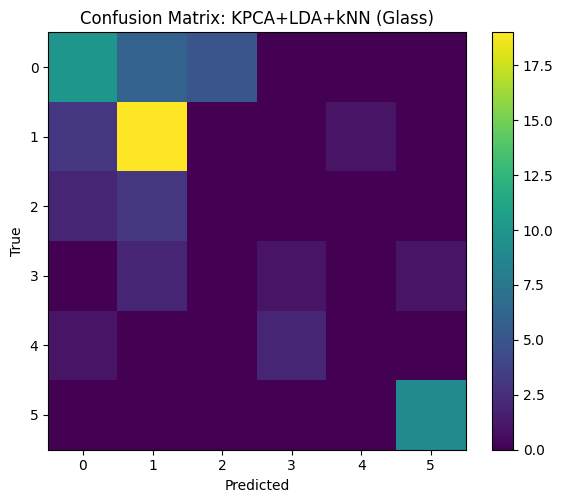

In [17]:
plt.figure(figsize=(6,5))
plt.imshow(cm_knn, interpolation="nearest")
plt.title("Confusion Matrix: KPCA+LDA+kNN (Glass)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()
plt.show()


## 2) KPCA + LDA + NCC (Grid Search)

In [20]:
pipe_ncc = Pipeline([
    ("scaler", StandardScaler()),
    ("kpca", KernelPCA(fit_inverse_transform=False, random_state=0)),
    ("lda", LinearDiscriminantAnalysis()),
    ("clf", NearestCentroid())
])


In [18]:
ncc_param_grid = []

# RBF
for kpca_n in kpca_dims:
    ncc_param_grid.append({
        "kpca__kernel": ["rbf"],
        "kpca__n_components": [kpca_n],
        "kpca__gamma": [0.1, 0.5, 1.0, 2.0, 5.0],
        "lda__n_components": valid_lda_components(kpca_n),
        "clf__metric": ["euclidean", "manhattan"],
        "clf__shrink_threshold": [None, 0.05, 0.1, 0.5, 1.0],
    })

# Polynomial
for kpca_n in kpca_dims:
    ncc_param_grid.append({
        "kpca__kernel": ["poly"],
        "kpca__n_components": [kpca_n],
        "kpca__gamma": [0.1, 0.5, 1.0],
        "kpca__degree": [2, 3],
        "kpca__coef0": [0.0, 1.0],
        "lda__n_components": valid_lda_components(kpca_n),
        "clf__metric": ["euclidean", "manhattan"],
        "clf__shrink_threshold": [None, 0.05, 0.1, 0.5, 1.0],
    })

print("Total NCC candidates (param dicts):", len(ncc_param_grid))


Total NCC candidates (param dicts): 10


In [21]:
ncc_grid = GridSearchCV(
    estimator=pipe_ncc,
    param_grid=ncc_param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    error_score="raise"
)

start = time.perf_counter()
ncc_grid.fit(X_train, y_train)
ncc_time = time.perf_counter() - start

print("Best NCC params:")
print(ncc_grid.best_params_)
print("Best CV accuracy:", ncc_grid.best_score_)
print(f"Grid search time: {ncc_time:.2f} sec")


Best NCC params:
{'clf__metric': 'euclidean', 'clf__shrink_threshold': 1.0, 'kpca__gamma': 0.1, 'kpca__kernel': 'rbf', 'kpca__n_components': 7, 'lda__n_components': 4}
Best CV accuracy: 0.5981609195402299
Grid search time: 13.21 sec


In [22]:
best_ncc = ncc_grid.best_estimator_

y_pred_ncc = best_ncc.predict(X_test)
acc_ncc = accuracy_score(y_test, y_pred_ncc)
f1m_ncc = f1_score(y_test, y_pred_ncc, average="macro")
f1w_ncc = f1_score(y_test, y_pred_ncc, average="weighted")

print("\n=== Test metrics (KPCA+LDA+NCC) ===")
print(f"Accuracy      : {acc_ncc:.4f}")
print(f"F1 macro      : {f1m_ncc:.4f}")
print(f"F1 weighted   : {f1w_ncc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_ncc))

cm_ncc = confusion_matrix(y_test, y_pred_ncc)
print("Confusion matrix:\n", cm_ncc)



=== Test metrics (KPCA+LDA+NCC) ===
Accuracy      : 0.5231
F1 macro      : 0.4685
F1 weighted   : 0.5435

Classification report:
              precision    recall  f1-score   support

           0       0.58      0.52      0.55        21
           1       0.73      0.48      0.58        23
           2       0.00      0.00      0.00         5
           3       0.44      1.00      0.62         4
           4       0.17      0.67      0.27         3
           5       1.00      0.67      0.80         9

    accuracy                           0.52        65
   macro avg       0.49      0.56      0.47        65
weighted avg       0.62      0.52      0.54        65

Confusion matrix:
 [[11  2  1  0  7  0]
 [ 5 11  3  2  2  0]
 [ 3  2  0  0  0  0]
 [ 0  0  0  4  0  0]
 [ 0  0  0  1  2  0]
 [ 0  0  0  2  1  6]]


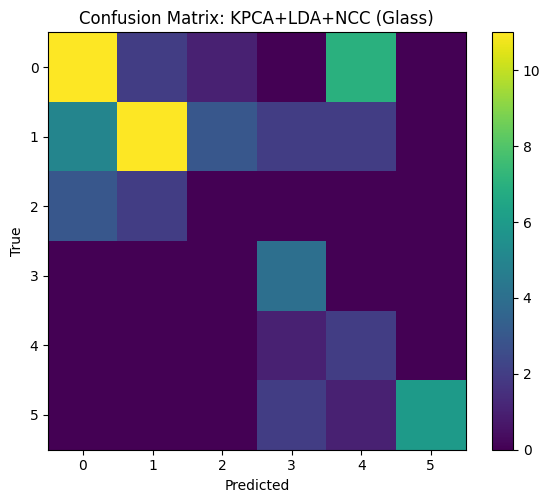

In [23]:
plt.figure(figsize=(6,5))
plt.imshow(cm_ncc, interpolation="nearest")
plt.title("Confusion Matrix: KPCA+LDA+NCC (Glass)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()
plt.show()


## Summary table

In [24]:
summary = [
    {
        "model": "KPCA+LDA+kNN",
        "cv_best_accuracy": knn_grid.best_score_,
        "test_accuracy": acc_knn,
        "test_f1_macro": f1m_knn,
        "test_f1_weighted": f1w_knn,
        "train_time_sec": knn_time,
        "best_params": knn_grid.best_params_,
    },
    {
        "model": "KPCA+LDA+NCC",
        "cv_best_accuracy": ncc_grid.best_score_,
        "test_accuracy": acc_ncc,
        "test_f1_macro": f1m_ncc,
        "test_f1_weighted": f1w_ncc,
        "train_time_sec": ncc_time,
        "best_params": ncc_grid.best_params_,
    }
]

for row in summary:
    print("\n" + row["model"])
    print(f"  CV best acc      : {row['cv_best_accuracy']:.4f}")
    print(f"  Test acc         : {row['test_accuracy']:.4f}")
    print(f"  Test F1 macro    : {row['test_f1_macro']:.4f}")
    print(f"  Test F1 weighted : {row['test_f1_weighted']:.4f}")
    print(f"  Train time (sec) : {row['train_time_sec']:.2f}")
    print(f"  Best params      : {row['best_params']}")



KPCA+LDA+kNN
  CV best acc      : 0.6982
  Test acc         : 0.6000
  Test F1 macro    : 0.4151
  Test F1 weighted : 0.5771
  Train time (sec) : 48.67
  Best params      : {'clf__metric': 'euclidean', 'clf__n_neighbors': 5, 'clf__weights': 'distance', 'kpca__coef0': 1.0, 'kpca__degree': 2, 'kpca__gamma': 0.1, 'kpca__kernel': 'poly', 'kpca__n_components': 5, 'lda__n_components': 5}

KPCA+LDA+NCC
  CV best acc      : 0.5982
  Test acc         : 0.5231
  Test F1 macro    : 0.4685
  Test F1 weighted : 0.5435
  Train time (sec) : 13.21
  Best params      : {'clf__metric': 'euclidean', 'clf__shrink_threshold': 1.0, 'kpca__gamma': 0.1, 'kpca__kernel': 'rbf', 'kpca__n_components': 7, 'lda__n_components': 4}
